Probability distribution of the proton latent vectors to then find the deuterons. 

In [69]:
import numpy as np
import umap
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

In [88]:
latent_p = np.load('latent_p.npy'); print(latent_p.shape)
latent_d = np.load('latent_d.npy'); print(latent_d.shape)

latent_all = np.concatenate([latent_p, latent_d])
labels = np.concatenate([
    np.zeros(len(latent_p)),          # 0 = protons
    np.ones(len(latent_d))         # 1 = deuterons
])

(6291, 16)
(5115, 16)


/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_76306/170009718.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(latent_umap[:, 0], latent_umap[:, 1], s=8, cmap='tab20')


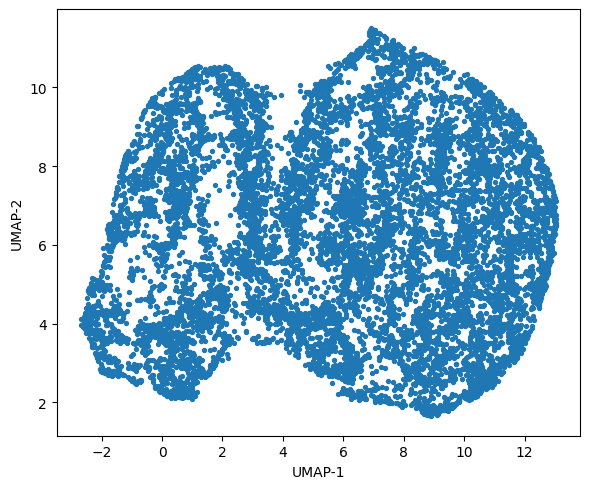

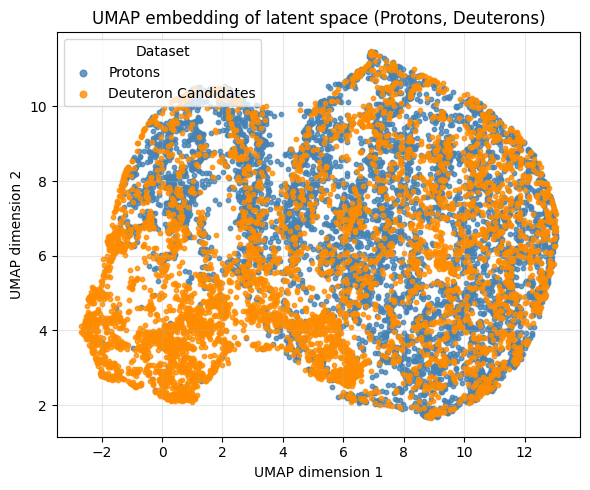

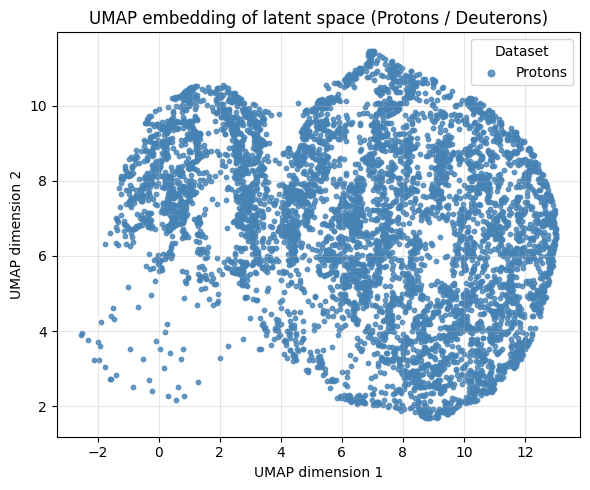

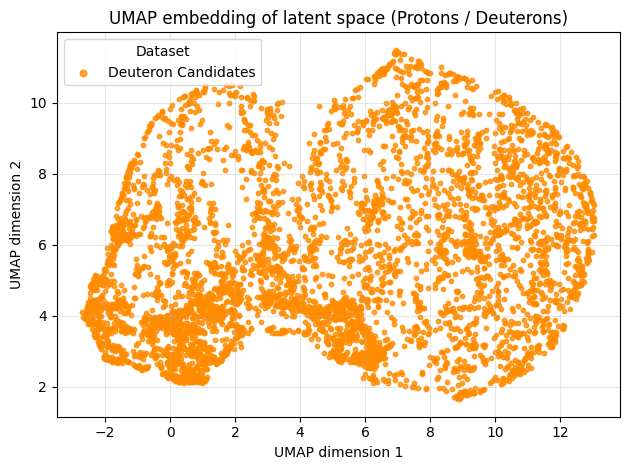

In [89]:
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)

latent_umap = reducer.fit_transform(latent_all)

plt.figure(figsize=(6,5))
plt.scatter(latent_umap[:, 0], latent_umap[:, 1], s=8, cmap='tab20')
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()

palette = ['steelblue', 'darkorange'] 

plt.figure(figsize=(6,5))
for i, name in enumerate(['Protons', 'Deuteron Candidates']):
    m = (labels == i)
    plt.scatter(latent_umap[m, 0], latent_umap[m, 1],
                color=palette[i], s=10, alpha=0.8, label=name)

plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.title("UMAP embedding of latent space (Protons, Deuterons)")
plt.legend(title="Dataset", markerscale=1.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
for i, name in enumerate(['Protons', 'Deuteron Candidates']):
    m = (labels == i)
    plt.scatter(latent_umap[m, 0], latent_umap[m, 1],
                color=palette[i], s=10, alpha=0.8, label=name)
    plt.xlabel("UMAP dimension 1")
    plt.ylabel("UMAP dimension 2")
    plt.title("UMAP embedding of latent space (Protons / Deuterons)")
    plt.legend(title="Dataset", markerscale=1.5)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [90]:
print("Has NaN:", np.isnan(latent_p).any())
print("Has Inf:", np.isinf(latent_p).any())
print("Min, Max:", np.min(latent_p), np.max(latent_p))
print("Mean std per dimension:", np.std(latent_p, axis=0))

Has NaN: False
Has Inf: False
Min, Max: -126.46029 122.26913
Mean std per dimension: [19.79551  19.231127 21.377674 25.032299 21.900362 20.477596 21.806711
 22.021332 18.369852 22.669516 20.048628 22.112131 17.872648 25.029387
 19.27069  19.744745]


In [91]:
p = StandardScaler().fit_transform(latent_p).astype(np.float64)
d = StandardScaler().fit_transform(latent_d).astype(np.float64)

all = np.concatenate([p, d])
labels = np.concatenate([
    np.zeros(len(p)),          # 0 = protons
    np.ones(len(d))         # 1 = deuterons
])

/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_76306/1725321528.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(latent_umap[:, 0], latent_umap[:, 1], s=8, cmap='tab20')


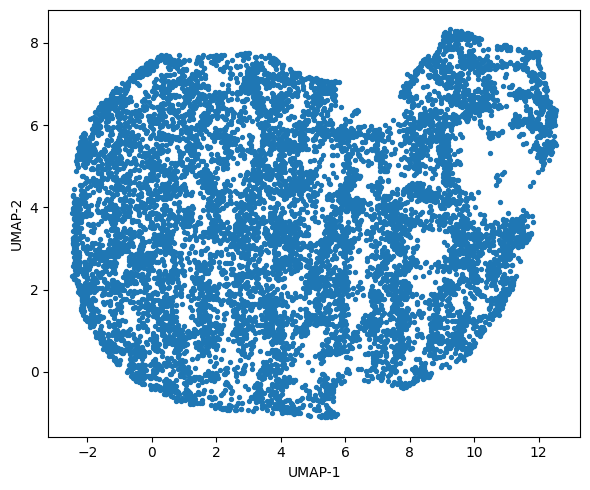

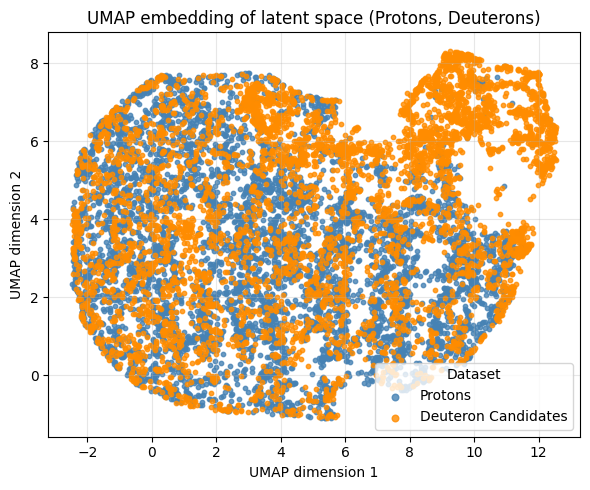

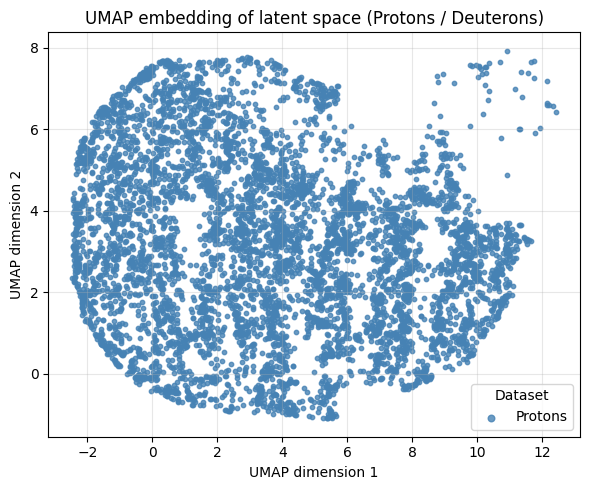

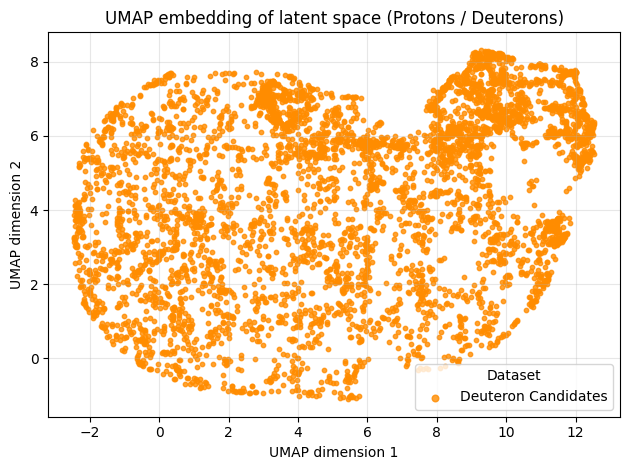

In [92]:
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)

latent_umap = reducer.fit_transform(all)

plt.figure(figsize=(6,5))
plt.scatter(latent_umap[:, 0], latent_umap[:, 1], s=8, cmap='tab20')
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()

palette = ['steelblue', 'darkorange'] 

plt.figure(figsize=(6,5))
for i, name in enumerate(['Protons', 'Deuteron Candidates']):
    m = (labels == i)
    plt.scatter(latent_umap[m, 0], latent_umap[m, 1],
                color=palette[i], s=10, alpha=0.8, label=name)

plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.title("UMAP embedding of latent space (Protons, Deuterons)")
plt.legend(title="Dataset", markerscale=1.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
for i, name in enumerate(['Protons', 'Deuteron Candidates']):
    m = (labels == i)
    plt.scatter(latent_umap[m, 0], latent_umap[m, 1],
                color=palette[i], s=10, alpha=0.8, label=name)
    plt.xlabel("UMAP dimension 1")
    plt.ylabel("UMAP dimension 2")
    plt.title("UMAP embedding of latent space (Protons / Deuterons)")
    plt.legend(title="Dataset", markerscale=1.5)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [93]:
print("Has NaN:", np.isnan(p).any())
print("Has Inf:", np.isinf(p).any())
print("Min, Max:", np.min(p), np.max(p))
print("Mean std per dimension:", np.std(p, axis=0))

Has NaN: False
Has Inf: False
Min, Max: -6.387491703033447 5.32012414932251
Mean std per dimension: [1.         1.         1.         0.99999999 1.         1.
 1.         1.         1.         1.00000001 0.99999999 1.
 1.         1.         1.         1.        ]


In [60]:
from sklearn.mixture import GaussianMixture

def fit_gmm_stable(X, k):
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',   # avoids ill-conditioned inversions
        init_params='random',     # avoid KMeans initialisation
        reg_covar=1e-3,           # strong stabiliser; can later reduce
        n_init=5,
        max_iter=500,
        random_state=42
    )
    gmm.fit(X)
    return gmm

for k in range(1, 50):
    g = fit_gmm_stable(p, k)
    print(f"k={k}, logL={g.score(p):.2f}, AIC={g.aic(p):.0f}, BIC={g.bic(p):.0f}")


k=1, logL=-20.44, AIC=257432, BIC=258457
k=2, logL=-14.00, AIC=176709, BIC=178767
k=3, logL=-12.06, AIC=152670, BIC=155760
k=4, logL=-10.87, AIC=137929, BIC=142052
k=5, logL=-10.00, AIC=127300, BIC=132455
k=6, logL=-8.84, AIC=113120, BIC=119307
k=7, logL=-8.25, AIC=105933, BIC=113152
k=8, logL=-7.58, AIC=97878, BIC=106129
k=9, logL=-7.10, AIC=92137, BIC=101421
k=10, logL=-6.90, AIC=89873, BIC=100189
k=11, logL=-6.37, AIC=83495, BIC=94843
k=12, logL=-6.09, AIC=80248, BIC=92629
k=13, logL=-5.88, AIC=77985, BIC=91398
k=14, logL=-5.64, AIC=75215, BIC=89660
k=15, logL=-5.45, AIC=73182, BIC=88659
k=16, logL=-5.07, AIC=68682, BIC=85191
k=17, logL=-5.25, AIC=71277, BIC=88819
k=18, logL=-4.70, AIC=64688, BIC=83262
k=19, logL=-4.72, AIC=65171, BIC=84777
k=20, logL=-4.70, AIC=65240, BIC=85878
k=21, logL=-4.60, AIC=64347, BIC=86018
k=22, logL=-4.49, AIC=63252, BIC=85955
k=23, logL=-4.40, AIC=62457, BIC=86193
k=24, logL=-4.04, AIC=58192, BIC=82959
k=25, logL=-4.19, AIC=60404, BIC=86204
k=26, logL=-

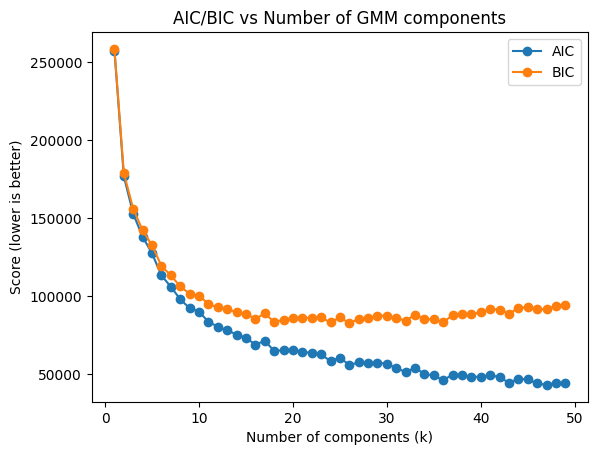

In [ ]:
K = list(range(1, 50))
AIC = [257432,176709,152670,137929,127300,113120,105933,97878,92137,89873,
       83495,80248,77985,75215,73182,68682,71277,64688,65171,65240,
       64347,63252,62457,58192,60404,55696,57323,56907,57261,56481,
       53661,51205,53927,49950,48989,45899,49597,49156,47961,48240,
       49150,47932,44226,46892,46405,43921,42913,44239,43908]
BIC = [258457,178767,155760,142052,132455,119307,113152,106129,101421,100189,
       94843,92629,91398,89660,88659,85191,88819,83262,84777,85878,
       86018,85955,86193,82959,86204,82528,85187,85804,87191,87442,
       85655,84231,87985,85040,85112,83054,87784,88375,88213,89524,
       91466,91281,88607,92305,92851,91399,91423,93781,94482]

plt.plot(K, AIC, label='AIC', marker='o')
plt.plot(K, BIC, label='BIC', marker='o')
plt.xlabel('Number of components (k)')
plt.ylabel('Score (lower is better)')
plt.legend()
plt.title('AIC/BIC vs Number of GMM components')
plt.show()


In [160]:
best_k = 15
best_gmm = fit_gmm_stable(p, best_k)

In [161]:
print("Weights:", best_gmm.weights_)
print("Means shape:", best_gmm.means_.shape)
print("Covariances shape:", best_gmm.covariances_.shape)

Weights: [0.06116721 0.05512757 0.05650369 0.03471237 0.17139071 0.1075587
 0.06281391 0.02968858 0.04900242 0.06468801 0.04753351 0.08595052
 0.02305148 0.08558127 0.06523006]
Means shape: (15, 16)
Covariances shape: (15, 16, 16)


/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


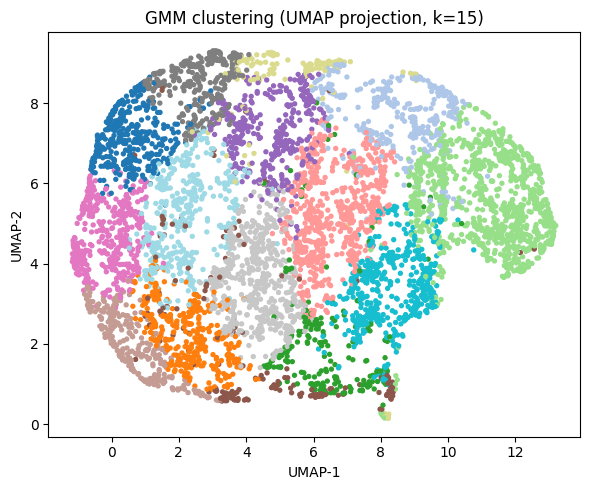

In [162]:
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
Z_umap = reducer.fit_transform(p)

labels = best_gmm.predict(p)

plt.figure(figsize=(6,5))
plt.scatter(Z_umap[:, 0], Z_umap[:, 1], c=labels, s=8, cmap='tab20')
plt.title(f"GMM clustering (UMAP projection, k={best_k})")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()

In [163]:
logL_d = best_gmm.score_samples(d)
logL_p = best_gmm.score_samples(p)

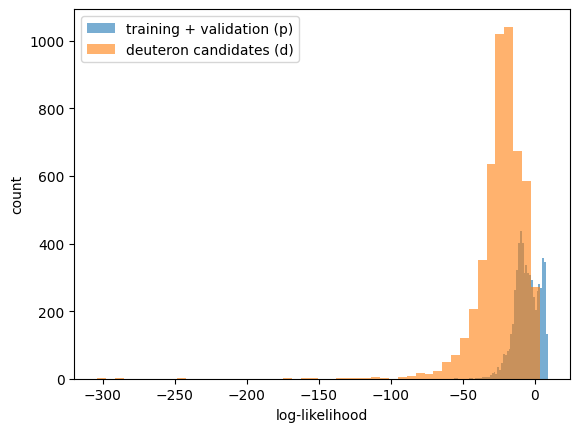

In [164]:
plt.hist(logL_p, bins=50, alpha=0.6, label='training + validation (p)')
plt.hist(logL_d, bins=50, alpha=0.6, label='deuteron candidates (d)')
plt.xlabel('log-likelihood')
plt.ylabel('count')
plt.legend()
plt.show()

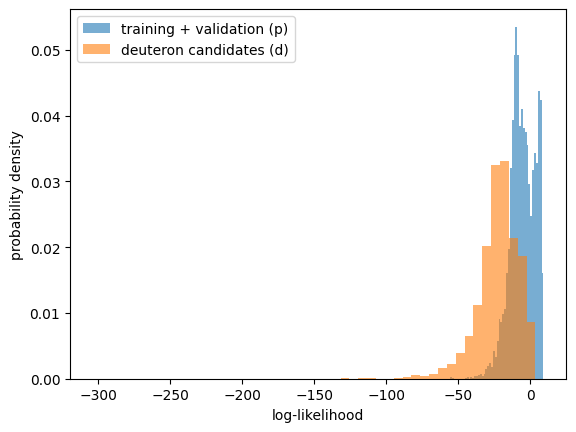

In [165]:
plt.hist(logL_p, bins=50, density=True, alpha=0.6, label='training + validation (p)')
plt.hist(logL_d, bins=50, density=True, alpha=0.6, label='deuteron candidates (d)')
plt.xlabel('log-likelihood')
plt.ylabel('probability density')
plt.legend()
plt.show()

Possible intersection points: [-14.37313463]


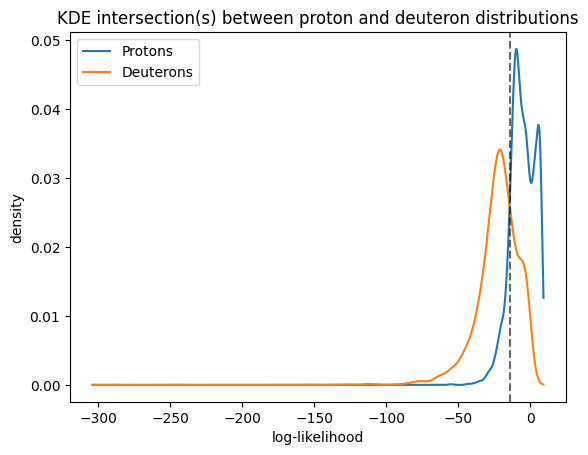

3657 / 5115 are isolated non-proton candidates.


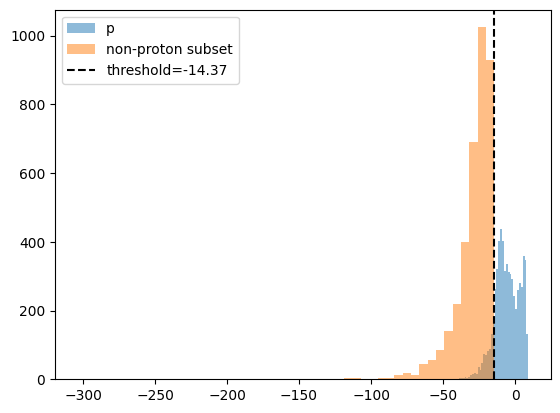

In [167]:
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

# KDE of both histograms
kde_p = gaussian_kde(logL_p)
kde_d = gaussian_kde(logL_d)

# Sample the likelihood axis finely
xs = np.linspace(min(logL_p.min(), logL_d.min()),
                 max(logL_p.max(), logL_d.max()), 2000)

# Density curves
fp = kde_p(xs)
fd = kde_d(xs)

# Intersection points = sign changes of fp - fd
diff = fp - fd
cross_idx = np.where(np.sign(diff[:-1]) != np.sign(diff[1:]))[0]

thresholds = 0.5 * (xs[cross_idx] + xs[cross_idx + 1])
print("Possible intersection points:", thresholds)

plt.plot(xs, fp, label='Protons')
plt.plot(xs, fd, label='Deuterons')
for t in thresholds:
    plt.axvline(t, color='k', linestyle='--', alpha=0.6)
plt.legend(); plt.xlabel('log-likelihood'); plt.ylabel('density');
plt.title('KDE intersection(s) between proton and deuteron distributions');
plt.show()

t = thresholds[0]   
non_proton_mask = logL_d < t

non_protons = d[non_proton_mask]
print(f"{non_proton_mask.sum()} / {len(d)} are isolated non-proton candidates.")

plt.hist(logL_p, bins=50, alpha=0.5, label='p')
plt.hist(logL_d[non_proton_mask], bins=50, alpha=0.5, label='non-proton subset')
plt.axvline(t, color='k', linestyle='--', label=f'threshold={t:.2f}')
plt.legend(); plt.show()

t_clean = t - np.std(logL_p)
non_protons_clean = d[logL_d < t_clean]

In [168]:
import numpy as np

# Concatenate both sets
check = np.concatenate([p, d], axis=0)

# Build labels:
#   0 = proton (training/validation)
#   1 = deuteron candidate
#   2 = deuteron that is "non-proton-like"
labels = np.concatenate([
    np.zeros(len(p), dtype=int),
    np.ones(len(d), dtype=int)
])
highlight_mask = np.zeros(len(check), dtype=bool)
highlight_mask[len(p):][non_proton_mask] = True  # mark only non-protons within d


/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


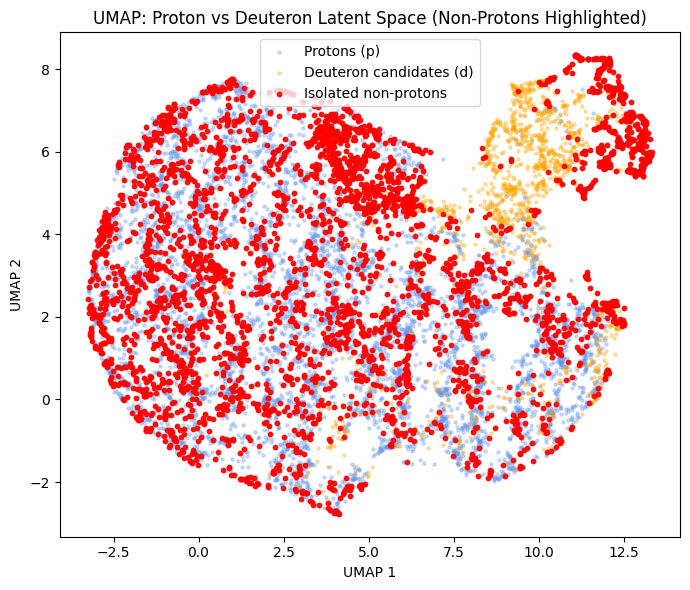

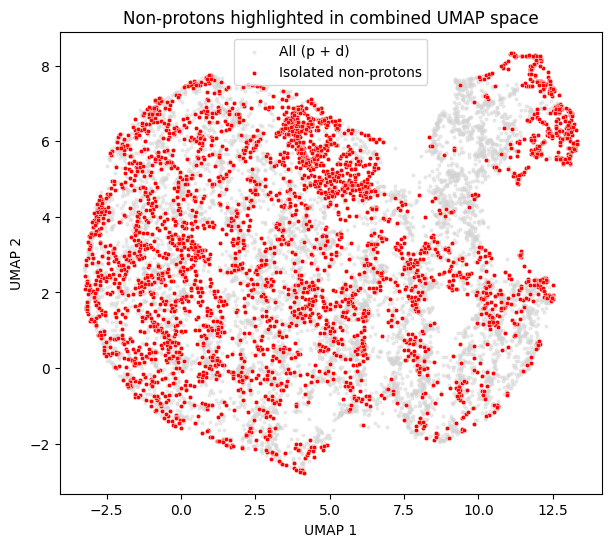

In [169]:
import umap
import matplotlib.pyplot as plt

umap_2d = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)

Z2D = umap_2d.fit_transform(check)

plt.figure(figsize=(7,6))

# background = protons (light blue)
plt.scatter(Z2D[labels==0,0], Z2D[labels==0,1],
            s=5, alpha=0.3, label='Protons (p)', color='cornflowerblue')

# deuteron candidates (light orange)
plt.scatter(Z2D[labels==1,0], Z2D[labels==1,1],
            s=5, alpha=0.3, label='Deuteron candidates (d)', color='orange')

# highlight isolated non-protons (red overlay)
plt.scatter(Z2D[highlight_mask,0], Z2D[highlight_mask,1],
            s=10, alpha=0.9, label='Isolated non-protons', color='red')

plt.legend()
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP: Proton vs Deuteron Latent Space (Non-Protons Highlighted)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,6))
plt.scatter(Z2D[:,0], Z2D[:,1],
            c='lightgrey', s=4, alpha=0.4, label='All (p + d)')
plt.scatter(Z2D[highlight_mask,0], Z2D[highlight_mask,1],
            c='red', s=10, edgecolor='white', linewidth=0.3,
            label='Isolated non-protons')
plt.legend()
plt.title('Non-protons highlighted in combined UMAP space')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()
